In [2]:
#!/usr/bin/env python
# coding: utf-8

In [3]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LeakyReLU, BatchNormalization, Dropout
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.regularizers import l2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import h5py
import os
import scipy.io
from scipy.interpolate import interp1d
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

<frozen importlib._bootstrap>:219: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject


Function to generate file names based on the input format

In [4]:
name_format = "FCNN_Bz_noprep_test"
print("Note: use results16.mat as train data, results17.m as test data; B only has positive Z values")
# file_path = os.path.join('MATLAB_DATA', 'results11.mat')  # Replace with your actual file path
def generate_filename(base_name, extension):
    return f"{name_format}_{base_name}.{extension}"

train_file_path = os.path.join('MATLAB_DATA', 'results16.mat')  # For training
test_file_path = os.path.join('MATLAB_DATA', 'results17.mat')   # For testing

Note: use results16.mat as train data, results17.m as test data; B only has positive Z values


In [5]:
h5_file_numbers = {3, 6, 7, 9}

Function to load data from .h5 file

In [6]:
def load_h5_data(file_path):
    with h5py.File(file_path, 'r') as hdf:
        results_group = hdf['results']
        B_MAG_refs = results_group['B_MAG'][()]
        EDC_MAG_refs = results_group['EDC_MAG'][()]
        X_refs = results_group['X'][()]
        I_refs = results_group['I'][()]
        B_MAG_raw = [hdf[ref][()] for ref in B_MAG_refs.flatten()]
        EDC_MAG_raw = [hdf[ref][()] for ref in EDC_MAG_refs.flatten()]
        X_raw = [hdf[ref][()] for ref in X_refs.flatten()]
        I_raw = [hdf[ref][()] for ref in I_refs.flatten()]
    return B_MAG_raw, EDC_MAG_raw, X_raw, I_raw

Function to load data from .mat file

In [7]:
def load_mat_data(file_path):
    mat_contents = scipy.io.loadmat(file_path)
    results = mat_contents['results']
    B_MAG_raw = [result['B_MAG'][0] for result in results[0]]
    EDC_MAG_raw = [result['EDC_MAG'][0] for result in results[0]]
    X_raw = [result['X'][0] for result in results[0]]  # Scaling X values
    I_raw = [result['I'][0] for result in results[0]]
    return B_MAG_raw, EDC_MAG_raw, X_raw, I_raw

Function to resample and smooth data

In [8]:
def resample_and_smooth(X, I, new_length):
    X_new = np.linspace(6562.3, 6563.3, num=new_length)
    f = interp1d(X, I, kind='cubic', fill_value="extrapolate")
    I_new = f(X_new)
    return X_new, I_new

Function to process data

In [9]:
def process_data(B_MAG_raw, EDC_MAG_raw, X_raw, I_raw, fixed_length=1200):
    X_data, I_data, B_MAG_data, EDC_MAG_data = [], [], [], []
    for i in range(len(X_raw)):
        X = np.squeeze(X_raw[i])
        I = np.squeeze(I_raw[i])
        B = np.squeeze(B_MAG_raw[i])
        EDC = np.squeeze(EDC_MAG_raw[i])
        X_scaled = X * 10**10
        X_resampled, I_resampled = resample_and_smooth(X_scaled, I, fixed_length)
        X_data.append(X_resampled)
        I_data.append(I_resampled)
        B_MAG_data.append(B)
        EDC_MAG_data.append(EDC)
    return np.array(B_MAG_data), np.array(EDC_MAG_data), np.array(X_data), np.array(I_data)

Main function to determine the type of file and load data accordingly

In [10]:
def load_and_process_file(file_path):
    file_name = os.path.basename(file_path)
    
    # Extract the file number (e.g., results1, results5, etc.)
    file_number = int(file_name.lstrip('results').rstrip('.mat'))
    
    if file_number in h5_file_numbers:
        # It's an HDF5 file
        print(f"Processing {file_name} as an HDF5 file...", flush=True)
        B_MAG_raw, EDC_MAG_raw, X_raw, I_raw = load_h5_data(file_path)
    else:
        # It's a standard .mat file
        print(f"Processing {file_name} as a .mat file...", flush=True)
        B_MAG_raw, EDC_MAG_raw, X_raw, I_raw = load_mat_data(file_path)
    
    # Process the loaded data
    B_MAG_data, EDC_MAG_data, X_data, I_data = process_data(B_MAG_raw, EDC_MAG_raw, X_raw, I_raw)
    
    return B_MAG_data, EDC_MAG_data, X_data, I_data

File paths for training and testing data

In [ ]:

# Load and process the training data
print("Loading training data...")
B_MAG_data_train, EDC_MAG_data_train, X_data_train, I_data_train = load_and_process_file(train_file_path)
# Load and process the testing data
print("Loading testing data...")
B_MAG_data_test, EDC_MAG_data_test, X_data_test, I_data_test = load_and_process_file(test_file_path)

Loading training data...
Processing results16.mat as a .mat file...
Loading testing data...
Processing results17.mat as a .mat file...


Data is now loaded and processed.

Note that must apply the same preprocessing steps to the test I data as you did for the training data

In [127]:
input_data_train = I_data_train.reshape(I_data_train.shape[0], -1)
input_data_test = I_data_test.reshape(I_data_test.shape[0], -1)

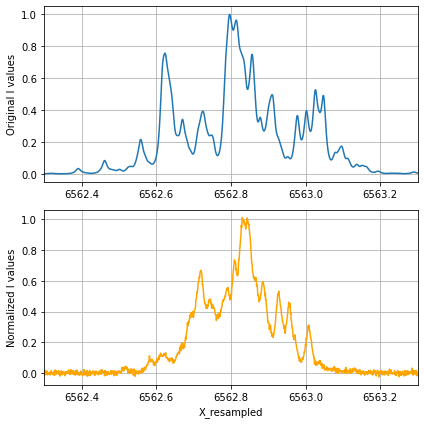

In [128]:
import matplotlib.pyplot as plt
# Row 10 of original and normalized data
index = 200
original_row = I_data_train[index]
normalized_row = I_data_test[index]
# original_row = I_data_train[index]
# normalized_row = I_data_test[index]
X_resampled_train=X_data_train[index]
X_resampled_test=X_data_test[index]

plt.figure(figsize=(6, 6))
plt.subplot(2, 1, 1)
plt.plot(X_resampled_train, original_row, label='Original I_data')
# plt.title('Original I_data values')
plt.ylabel('Original I values')
# plt.ylim(0, 1)
plt.xlim(6562.3, 6563.3)
plt.grid(True)
plt.subplot(2, 1, 2)
plt.plot(X_resampled_test, normalized_row, label='Normalized I_data', color='orange')
# plt.title('Normalized I_data values')
plt.xlabel('X_resampled')
plt.ylabel('Normalized I values')
plt.xlim(6562.3, 6563.3)
plt.grid(True)
plt.tight_layout()
plt.show()

Normalize target and target data

In [129]:
from sklearn.preprocessing import MinMaxScaler
# Create separate MinMaxScaler instances for each component
scaler_B3 = MinMaxScaler(feature_range=(0, 1))
scaler_E1 = MinMaxScaler(feature_range=(0, 1))
scaler_E2 = MinMaxScaler(feature_range=(0, 1))
scaler_E3 = MinMaxScaler(feature_range=(0, 1))

Prepare the target data for training

In [130]:
B3_train = B_MAG_data_train[:, 2].reshape(-1, 1)  # B3 component
E1_train = EDC_MAG_data_train[:, 0].reshape(-1, 1)  # E1 component
E2_train = EDC_MAG_data_train[:, 1].reshape(-1, 1)  # E2 component
E3_train = EDC_MAG_data_train[:, 2].reshape(-1, 1)  # E3 component

Scale the target data for training

In [131]:
B3_scaled_train = scaler_B3.fit_transform(B3_train)
E1_scaled_train = scaler_E1.fit_transform(E1_train)
E2_scaled_train = scaler_E2.fit_transform(E2_train)
E3_scaled_train = scaler_E3.fit_transform(E3_train)

Recombine the scaled components back into target_data

In [132]:
target_data_train = np.hstack((B3_scaled_train, E1_scaled_train, E2_scaled_train, E3_scaled_train))

Assuming B_MAG_data and EDC_MAG_data are loaded as NumPy arrays<br>
B3 is B_MAG_data[:, 2], and EDC_MAG_data consists of E1, E2, E3

In [133]:
B3_test = B_MAG_data_test[:, 2].reshape(-1, 1)  # B3 component
E1_test = EDC_MAG_data_test[:, 0].reshape(-1, 1)  # E1 component
E2_test = EDC_MAG_data_test[:, 1].reshape(-1, 1)  # E2 component
E3_test = EDC_MAG_data_test[:, 2].reshape(-1, 1)  # E3 component

Fit and transform each component separately

In [134]:
B3_scaled_test = scaler_B3.transform(B3_test)
E1_scaled_test = scaler_E1.transform(E1_test)
E2_scaled_test = scaler_E2.transform(E2_test)
E3_scaled_test = scaler_E3.transform(E3_test)

Recombine the scaled components back into target_data

In [135]:
target_data_test = np.hstack((B3_scaled_test, E1_scaled_test, E2_scaled_test, E3_scaled_test))

In [136]:
print("Data organized.", flush=True)

Data organized.


In [137]:
from tensorflow.keras.callbacks import Callback
class LossMonitor(Callback):
    def on_batch_end(self, batch, logs=None):
        if batch % 100 == 0:
            print(f"Batch {batch}: loss = {logs['loss']}")

In [138]:
def custom_loss(y_true, y_pred):
    B_true, E_true = y_true[:, :1], y_true[:, 1:]
    B_pred, E_pred = y_pred[:, :1], y_pred[:, 1:]
    loss_B = tf.reduce_mean(tf.square(B_true - B_pred), axis=0)
    loss_E = tf.reduce_mean(tf.square(E_true - E_pred), axis=0)
    weight_B = tf.constant([1.0])
    weight_E = tf.constant([1.0, 1.0, 1.0])
    total_loss = tf.reduce_sum(weight_B * loss_B) + tf.reduce_sum(weight_E * loss_E)
    return total_loss

In [139]:
model_save_path = os.path.join("/home/botingl/machine learning/FCNN_Bz_noprep_noise.h5")
model = tf.keras.models.load_model(model_save_path, custom_objects={'custom_loss': custom_loss})
print("Model loaded successfully.")

Model loaded successfully.


Whole model evaluation (NMSE, rMAE, R²)

In [140]:
def evaluate_whole_model(y_true, y_pred):
    nmse = mean_squared_error(y_true, y_pred) / np.var(y_true)
    rmae = mean_absolute_error(y_true, y_pred) / np.mean(np.abs(y_true))
    r2 = r2_score(y_true, y_pred)
    return nmse, rmae, r2

Component-wise evaluation (MSE, MAE, R²)

In [141]:
def evaluate_components(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return mse, mae, r2

Evaluation metrics for the training data

In [142]:
print("Start to evaluate the training set.", flush=True)
# np.random.seed(42)
# subset_indices = np.random.choice(len(input_data_train), size=1000, replace=False)
# train_input_data_subset = input_data_train[subset_indices]
# train_target_data_subset = target_data_train[subset_indices]

Start to evaluate the training set.


In [143]:
import time

# Measure the time taken for the entire prediction process
start_time = time.time()

# Make predictions on the training data
predictions_train = model.predict(input_data_train)

# Measure the end time
end_time = time.time()

# Calculate and print the time taken
time_taken = end_time - start_time
print(f"Time taken for prediction on the entire training set: {time_taken:.6f} seconds")

num_input = len(input_data_train)
time_each = time_taken/num_input
print(f"Time taken for prediction on each training set: {time_each:.6f} seconds")


313/313 [==============================] - 1s 2ms/step
Time taken for prediction on the entire training set: 0.717361 seconds
Time taken for prediction on each training set: 0.000072 seconds


Scale back the predicted values to original range

In [144]:
B_pred_train = scaler_B3.inverse_transform(predictions_train[:, 0].reshape(-1, 1))
E_pred_train = np.column_stack((
    scaler_E1.inverse_transform(predictions_train[:, 1].reshape(-1, 1)),
    scaler_E2.inverse_transform(predictions_train[:, 2].reshape(-1, 1)),
    scaler_E3.inverse_transform(predictions_train[:, 3].reshape(-1, 1))
))

Scale back the true values to original range

In [145]:
B_true_train = scaler_B3.inverse_transform(target_data_train[:, 0].reshape(-1, 1))
E_true_train = np.column_stack((
    scaler_E1.inverse_transform(target_data_train[:, 1].reshape(-1, 1)),
    scaler_E2.inverse_transform(target_data_train[:, 2].reshape(-1, 1)),
    scaler_E3.inverse_transform(target_data_train[:, 3].reshape(-1, 1))
))

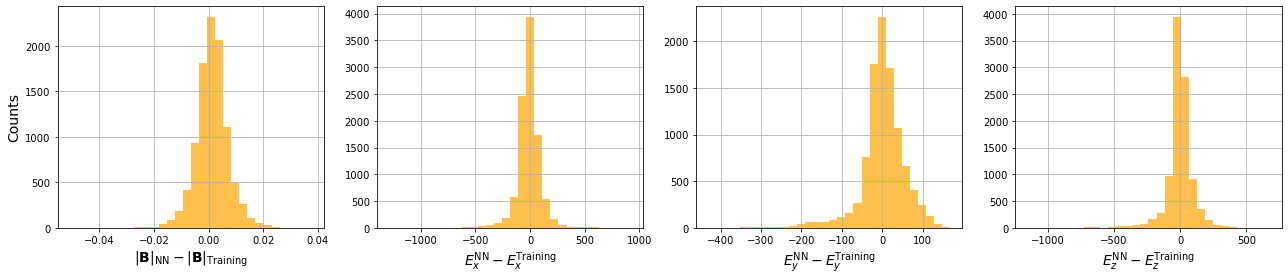

In [146]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming you have already calculated the following:
# B_true_test, B_pred_test, E_true_test, E_pred_test

# Step 1: Calculate the errors for B3, E1, E2, E3 components
B3_error_train = B_true_train - B_pred_train
E1_error_train = E_true_train[:, 0] - E_pred_train[:, 0]
E2_error_train = E_true_train[:, 1] - E_pred_train[:, 1]
E3_error_train = E_true_train[:, 2] - E_pred_train[:, 2]

# Step 2: Plot the error histograms
plt.figure(figsize=(18, 4))  # Adjust figure size to match the layout in your image

# Plot B3 error
plt.subplot(1, 4, 1)
plt.hist(B3_error_train, bins=30, color='orange', alpha=0.7)
plt.xlabel(r'$|\mathbf{B}|_{\mathrm{NN}} - |\mathbf{B}|_{\mathrm{Training}}$', fontsize=14)
plt.ylabel('Counts', fontsize=14)
# plt.xlim([-0.2, 0.2])  # Adjust limits to match your plot
plt.grid(True)

# Plot E1 error
plt.subplot(1, 4, 2)
plt.hist(E1_error_train, bins=30, color='orange', alpha=0.7)
plt.xlabel(r'$E_x^{\mathrm{NN}} - E_x^{\mathrm{Training}}$', fontsize=14)
# plt.xlim([-0.2, 0.2])
plt.grid(True)

# Plot E2 error
plt.subplot(1, 4, 3)
plt.hist(E2_error_train, bins=30, color='orange', alpha=0.7)
plt.xlabel(r'$E_y^{\mathrm{NN}} - E_y^{\mathrm{Training}}$', fontsize=14)
# plt.xlim([-0.2, 0.2])
plt.grid(True)

# Plot E3 error
plt.subplot(1, 4, 4)
plt.hist(E3_error_train, bins=30, color='orange', alpha=0.7)
plt.xlabel(r'$E_z^{\mathrm{NN}} - E_z^{\mathrm{Training}}$', fontsize=14)
# plt.xlim([-0.2, 0.2])
plt.grid(True)

# Adjust layout
plt.tight_layout()
plt.show()


Combine the scaled-back true and predicted values for evaluation

In [147]:
true_train_combined = np.column_stack((B_true_train, E_true_train))
pred_train_combined = np.column_stack((B_pred_train, E_pred_train))

Whole model evaluation

In [148]:
nmse_train, rmae_train, r2_whole_model_train = evaluate_whole_model(true_train_combined, pred_train_combined)
print(f"Whole Model NMSE: {nmse_train}, rMAE: {rmae_train}, R²: {r2_whole_model_train}")

Whole Model NMSE: 0.01703652051011097, rMAE: 0.05885433318606251, R²: 0.9762771390362511


Component-wise evaluation

In [149]:
mse_train_B3, mae_train_B3, r2_train_B3 = evaluate_components(B_true_train, B_pred_train)
mse_train_E1, mae_train_E1, r2_train_E1 = evaluate_components(E_true_train[:, 0], E_pred_train[:, 0])
mse_train_E2, mae_train_E2, r2_train_E2 = evaluate_components(E_true_train[:, 1], E_pred_train[:, 1])
mse_train_E3, mae_train_E3, r2_train_E3 = evaluate_components(E_true_train[:, 2], E_pred_train[:, 2])

Output the evaluation for each component

In [150]:
print(f"B3: MSE = {mse_train_B3}, MAE = {mae_train_B3}, R² = {r2_train_B3}")
print(f"E1: MSE = {mse_train_E1}, MAE = {mae_train_E1}, R² = {r2_train_E1}")
print(f"E2: MSE = {mse_train_E2}, MAE = {mae_train_E2}, R² = {r2_train_E2}")
print(f"E3: MSE = {mse_train_E3}, MAE = {mae_train_E3}, R² = {r2_train_E3}")

B3: MSE = 3.7546532468524116e-05, MAE = 0.004558805929470785, R² = 0.9949834265502357
E1: MSE = 14331.153619944096, MAE = 74.79306394415646, R² = 0.9571846375133533
E2: MSE = 3047.8525453244, MAE = 37.51100594101539, R² = 0.9907961364509877
E3: MSE = 12717.906550000176, MAE = 66.0118242541495, R² = 0.9621443556304276


Save evaluation metrics to a text file

In [151]:
# metrics_train_file = os.path.join("/home/botingl/machine learning", generate_filename("evaluation_metrics_train", "txt"))
# with open(metrics_train_file, "w") as f:
#     f.write(f"Whole Model: NMSE: {nmse_train}, rMAE: {rmae_train}, R²: {r2_whole_model_train}\n")
#     f.write(f"B3: MSE = {mse_train_B3}, MAE = {mae_train_B3}, R² = {r2_train_B3}\n")
#     f.write(f"E1: MSE = {mse_train_E1}, MAE = {mae_train_E1}, R² = {r2_train_E1}\n")
#     f.write(f"E2: MSE = {mse_train_E2}, MAE = {mae_train_E2}, R² = {r2_train_E2}\n")
#     f.write(f"E3: MSE = {mse_train_E3}, MAE = {mae_train_E3}, R² = {r2_train_E3}\n")

Plot the true vs. predicted B and E values for the training set

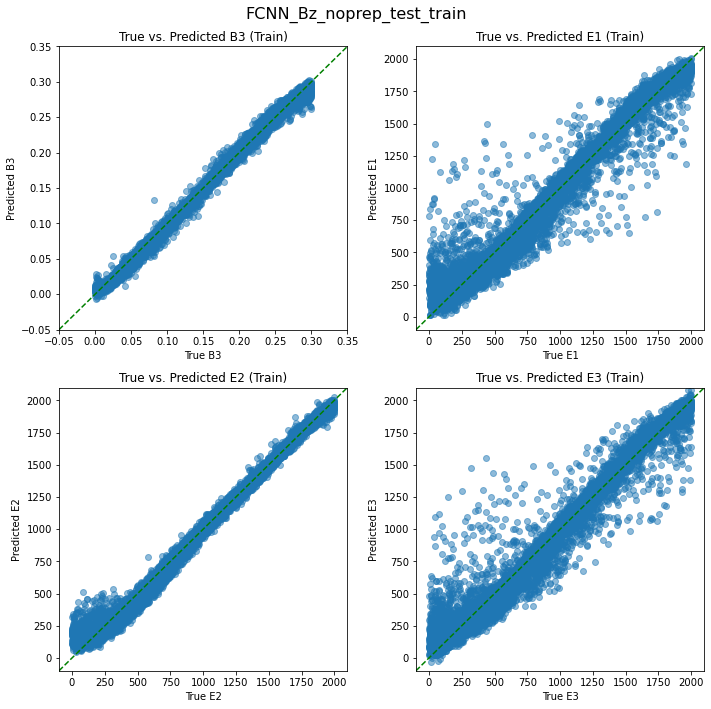

In [152]:
plt.figure(figsize=(10, 10))
plt.subplot(2, 2, 1)
plt.scatter(B_true_train, B_pred_train, alpha=0.5)
plt.plot([-0.05, 1.1], [-0.05, 1.1], 'g--')
plt.xlim(-0.05, 0.35)
plt.ylim(-0.05, 0.35)
plt.xlabel('True B3')
plt.ylabel('Predicted B3')
plt.title('True vs. Predicted B3 (Train)')

plt.subplot(2, 2, 2)
plt.scatter(E_true_train[:, 0], E_pred_train[:, 0], alpha=0.5)
plt.plot([-100, 2100], [-100, 2100], 'g--')
plt.xlim(-100, 2100)
plt.ylim(-100, 2100)
plt.xlabel('True E1')
plt.ylabel('Predicted E1')
plt.title('True vs. Predicted E1 (Train)')

plt.subplot(2, 2, 3)
plt.scatter(E_true_train[:, 1], E_pred_train[:, 1], alpha=0.5)
plt.plot([-100, 2100], [-100, 2100], 'g--')
plt.xlim(-100, 2100)
plt.ylim(-100, 2100)
plt.xlabel('True E2')
plt.ylabel('Predicted E2')
plt.title('True vs. Predicted E2 (Train)')

plt.subplot(2, 2, 4)
plt.scatter(E_true_train[:, 2], E_pred_train[:, 2], alpha=0.5)
plt.plot([-100, 2100], [-100, 2100], 'g--')
plt.xlim(-100, 2100)
plt.ylim(-100, 2100)
plt.xlabel('True E3')
plt.ylabel('Predicted E3')
plt.title('True vs. Predicted E3 (Train)')

plt.suptitle(f'{name_format}_train', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 1])  # Adjust layout to avoid overlap with suptitle
figure_test_file = os.path.join("/home/botingl/machine learning", generate_filename("true_vs_predictions_train", "png"))
# plt.savefig(figure_test_file, dpi=300, facecolor='white')
plt.show()

In [153]:
print("Training set evaluation done.", flush=True)

Training set evaluation done.


Evaluate the model on the testing set

In [154]:
print("Start to evaluate the testing set.", flush=True)

Start to evaluate the testing set.


In [155]:
import time

# Measure the time taken for the entire prediction process
start_time = time.time()

# Make predictions on the training data
predictions_test = model.predict(input_data_test)

# Measure the end time
end_time = time.time()

# Calculate and print the time taken
time_taken = end_time - start_time
print(f"Time taken for prediction on the entire testing set: {time_taken:.4f} seconds")

um_input = len(input_data_test)
time_each = time_taken/num_input
print(f"Time taken for prediction on each testing set: {time_each:.6f} seconds")


 32/313 [==>...........................] - ETA: 0s

313/313 [==============================] - 1s 2ms/step
Time taken for prediction on the entire testing set: 0.6201 seconds
Time taken for prediction on each testing set: 0.000062 seconds


Scale back the predicted values to original range for the test data

In [156]:
B_pred_test = scaler_B3.inverse_transform(predictions_test[:, 0].reshape(-1, 1))

In [157]:
E_pred_test = np.column_stack((
    scaler_E1.inverse_transform(predictions_test[:, 1].reshape(-1, 1)),
    scaler_E2.inverse_transform(predictions_test[:, 2].reshape(-1, 1)),
    scaler_E3.inverse_transform(predictions_test[:, 3].reshape(-1, 1))
))

Scale back the true values to original range for the test data

In [158]:
B_true_test = scaler_B3.inverse_transform(target_data_test[:, 0].reshape(-1, 1))

In [159]:
E_true_test = np.column_stack((
    scaler_E1.inverse_transform(target_data_test[:, 1].reshape(-1, 1)),
    scaler_E2.inverse_transform(target_data_test[:, 2].reshape(-1, 1)),
    scaler_E3.inverse_transform(target_data_test[:, 3].reshape(-1, 1))
))

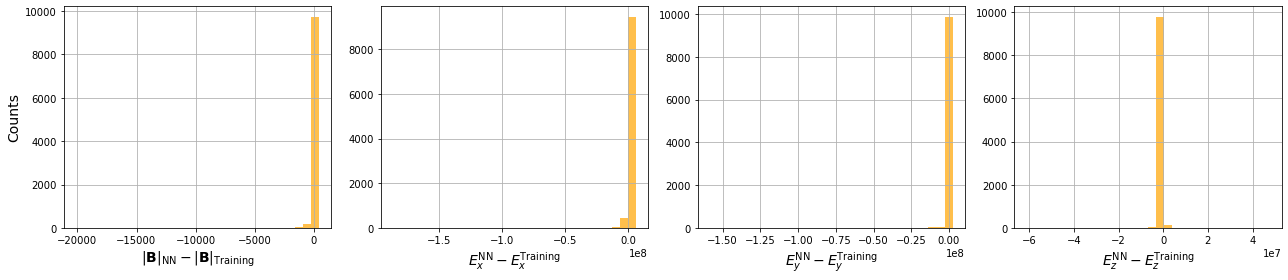

In [160]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming you have already calculated the following:
# B_true_test, B_pred_test, E_true_test, E_pred_test

# Step 1: Calculate the errors for B3, E1, E2, E3 components
B3_error = B_true_test - B_pred_test
E1_error = E_true_test[:, 0] - E_pred_test[:, 0]
E2_error = E_true_test[:, 1] - E_pred_test[:, 1]
E3_error = E_true_test[:, 2] - E_pred_test[:, 2]

# Step 2: Plot the error histograms
plt.figure(figsize=(18, 4))  # Adjust figure size to match the layout in your image

# Plot B3 error
plt.subplot(1, 4, 1)
plt.hist(B3_error, bins=30, color='orange', alpha=0.7)
plt.xlabel(r'$|\mathbf{B}|_{\mathrm{NN}} - |\mathbf{B}|_{\mathrm{Training}}$', fontsize=14)
plt.ylabel('Counts', fontsize=14)
# plt.xlim([-0.2, 0.2])  # Adjust limits to match your plot
plt.grid(True)

# Plot E1 error
plt.subplot(1, 4, 2)
plt.hist(E1_error, bins=30, color='orange', alpha=0.7)
plt.xlabel(r'$E_x^{\mathrm{NN}} - E_x^{\mathrm{Training}}$', fontsize=14)
# plt.xlim([-0.2, 0.2])
plt.grid(True)

# Plot E2 error
plt.subplot(1, 4, 3)
plt.hist(E2_error, bins=30, color='orange', alpha=0.7)
plt.xlabel(r'$E_y^{\mathrm{NN}} - E_y^{\mathrm{Training}}$', fontsize=14)
# plt.xlim([-0.2, 0.2])
plt.grid(True)

# Plot E3 error
plt.subplot(1, 4, 4)
plt.hist(E3_error, bins=30, color='orange', alpha=0.7)
plt.xlabel(r'$E_z^{\mathrm{NN}} - E_z^{\mathrm{Training}}$', fontsize=14)
# plt.xlim([-0.2, 0.2])
plt.grid(True)

# Adjust layout
plt.tight_layout()
plt.show()


Combine the scaled-back true and predicted values for evaluation (test data)

In [161]:
true_test_combined = np.column_stack((B_true_test, E_true_test))
pred_test_combined = np.column_stack((B_pred_test, E_pred_test))

In [162]:
# Set manual bounds for each component (based on domain knowledge)
bounds = {
    "B3": (-0.1, 0.35),
    "E1": (-100, 2200),
    "E2": (-100, 2200),
    "E3": (-100, 2200)
}

# Ensure all conditions are 1D arrays
valid_B3 = (B_pred_test.flatten() >= bounds['B3'][0]) & (B_pred_test.flatten() <= bounds['B3'][1])
valid_E1 = (E_pred_test[:, 0] >= bounds['E1'][0]) & (E_pred_test[:, 0] <= bounds['E1'][1])
valid_E2 = (E_pred_test[:, 1] >= bounds['E2'][0]) & (E_pred_test[:, 1] <= bounds['E2'][1])
valid_E3 = (E_pred_test[:, 2] >= bounds['E3'][0]) & (E_pred_test[:, 2] <= bounds['E3'][1])

# Combine all valid conditions (they should all be 1D arrays now)
valid_indices = valid_B3 & valid_E1 & valid_E2 & valid_E3

# Filter based on valid indices
filtered_pred_test_combined = pred_test_combined[valid_indices]
filtered_true_test_combined = true_test_combined[valid_indices]

print(f"Filtered out {len(pred_test_combined) - len(filtered_pred_test_combined)} outliers based on manual thresholds.")


Filtered out 1333 outliers based on manual thresholds.


Whole model evaluation

In [163]:
nmse_test, rmae_test, r2_whole_model_test = evaluate_whole_model(filtered_true_test_combined, filtered_pred_test_combined)
print(f"Whole Model NMSE: {nmse_test}, rMAE: {rmae_test}, R²: {r2_whole_model_test}")

Whole Model NMSE: 0.02215223977898449, rMAE: 0.05774267652285443, R²: 0.9634148703788799


Component-wise evaluation

In [164]:
mse_test_B3, mae_test_B3, r2_test_B3 = evaluate_components(B_true_test, B_pred_test)
mse_test_E1, mae_test_E1, r2_test_E1 = evaluate_components(E_true_test[:, 0], E_pred_test[:, 0])
mse_test_E2, mae_test_E2, r2_test_E2 = evaluate_components(E_true_test[:, 1], E_pred_test[:, 1])
mse_test_E3, mae_test_E3, r2_test_E3 = evaluate_components(E_true_test[:, 2], E_pred_test[:, 2])

Output the evaluation for each component

In [165]:
print(f"B3: MSE = {mse_test_B3}, MAE = {mae_test_B3}, R² = {r2_test_B3}")
print(f"E1: MSE = {mse_test_E1}, MAE = {mae_test_E1}, R² = {r2_test_E1}")
print(f"E2: MSE = {mse_test_E2}, MAE = {mae_test_E2}, R² = {r2_test_E2}")
print(f"E3: MSE = {mse_test_E3}, MAE = {mae_test_E3}, R² = {r2_test_E3}")

B3: MSE = 276319.5017326729, MAE = 50.02670614894519, R² = -36920958.01188023
E1: MSE = 13737121583385.553, MAE = 335399.33912154305, R² = -41039997.36523062
E2: MSE = 7620932195651.313, MAE = 253164.28247627302, R² = -23014487.971654505
E3: MSE = 2246874006762.816, MAE = 145471.53619230972, R² = -6683967.169044088


Save evaluation metrics to a text file

In [166]:
# metrics_train_file = os.path.join("/home/botingl/machine learning", generate_filename("evaluation_metrics_test", "txt"))
# with open(metrics_train_file, "w") as f:
#     f.write(f"Whole Model: NMSE: {nmse_test}, rMAE: {rmae_test}, R²: {r2_whole_model_test}\n")
#     f.write(f"B3: MSE = {mse_test_B3}, MAE = {mae_test_B3}, R² = {r2_test_B3}\n")
#     f.write(f"E1: MSE = {mse_test_E1}, MAE = {mae_test_E1}, R² = {r2_test_E1}\n")
#     f.write(f"E2: MSE = {mse_test_E2}, MAE = {mae_test_E2}, R² = {r2_test_E2}\n")
#     f.write(f"E3: MSE = {mse_test_E3}, MAE = {mae_test_E3}, R² = {r2_test_E3}\n")

Plot the true vs. predicted B and E values for the test set

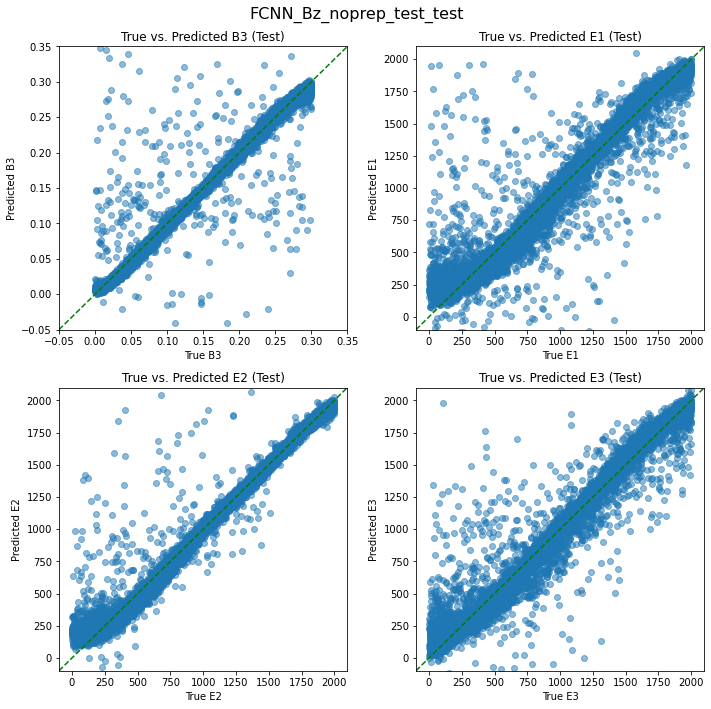

In [167]:
plt.figure(figsize=(10, 10))
plt.subplot(2, 2, 1)
plt.scatter(B_true_test, B_pred_test, alpha=0.5)
plt.plot([-0.05, 1.1], [-0.05, 1.1], 'g--')
plt.xlim(-0.05, 0.35)
plt.ylim(-0.05, 0.35)
plt.xlabel('True B3')
plt.ylabel('Predicted B3')
plt.title('True vs. Predicted B3 (Test)')

plt.subplot(2, 2, 2)
plt.scatter(E_true_test[:, 0], E_pred_test[:, 0], alpha=0.5)
plt.plot([-100, 2100], [-100, 2100], 'g--')
plt.xlim(-100, 2100)
plt.ylim(-100, 2100)
plt.xlabel('True E1')
plt.ylabel('Predicted E1')
plt.title('True vs. Predicted E1 (Test)')

plt.subplot(2, 2, 3)
plt.scatter(E_true_test[:, 1], E_pred_test[:, 1], alpha=0.5)
plt.plot([-100, 2100], [-100, 2100], 'g--')
plt.xlim(-100, 2100)
plt.ylim(-100, 2100)
plt.xlabel('True E2')
plt.ylabel('Predicted E2')
plt.title('True vs. Predicted E2 (Test)')

plt.subplot(2, 2, 4)
plt.scatter(E_true_test[:, 2], E_pred_test[:, 2], alpha=0.5)
plt.plot([-100, 2100], [-100, 2100], 'g--')
plt.xlim(-100, 2100)
plt.ylim(-100, 2100)
plt.xlabel('True E3')
plt.ylabel('Predicted E3')
plt.title('True vs. Predicted E3 (Test)')

plt.suptitle(f'{name_format}_test', fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 1])  # Adjust layout to avoid overlap with suptitle
figure_test_file = os.path.join("/home/botingl/machine learning", generate_filename("true_vs_predictions_test", "png"))
# plt.savefig(figure_test_file, dpi=300, facecolor='white')
plt.show()

In [168]:
print("Testing set evaluation done.", flush=True)

Testing set evaluation done.
